# 03 — FOV46 Leiden sweep and manual resolution selection

This is the **mandatory checkpoint**. Run resolutions 0.1–1.0, inspect UMAP/markers/spatial structure, and do not proceed until a resolution is chosen.

In [1]:
from pathlib import Path
import sys, os

# Notebook lives in PROJECT_ROOT/jupyter/.
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "jupyter" else Path.cwd().resolve()
sys.path.insert(0, str(PROJECT_ROOT))
print("PROJECT_ROOT:", PROJECT_ROOT)
print("Python:", sys.executable)
assert (PROJECT_ROOT / "scripts").exists(), "Run this notebook from PROJECT_ROOT/jupyter or PROJECT_ROOT."

PROJECT_ROOT: /research/rgs01/home/clusterHome/jqu/activities/learning/BioHackathon/BioHackathon-2026/Dataset_02_CosMx_revised/Dataset_02_CosMx_revised
Python: /home/jqu/.conda/envs/spatialdata/bin/python


## Production sweep

In [ ]:
%run ../scripts/04b_leiden_sweep_fov46.py

## Interactive summary

In [2]:
import pandas as pd, scanpy as sc
from IPython.display import display
TAB=PROJECT_ROOT/"results/FOV46/tables"
summary=pd.read_csv(TAB/"leiden_resolution_sweep.csv")
display(summary)

,resolution,key,n_clusters,min_cluster_size,median_cluster_size,tiny_cluster_fraction,ARI_vs_previous,NMI_vs_previous
0,0.1,leiden_r0.1,2,139,469.0,0.000000,NaN,NaN
1,0.2,leiden_r0.2,2,139,469.0,0.000000,1.000000,1.000000
2,0.3,leiden_r0.3,3,140,155.0,0.000000,0.533389,0.656016
3,0.4,leiden_r0.4,4,141,236.0,0.000000,0.522606,0.741081
4,0.5,leiden_r0.5,4,142,186.0,0.000000,0.683548,0.782406
5,0.6,leiden_r0.6,6,17,139.0,0.018124,0.837224,0.843635
6,0.7,leiden_r0.7,7,15,135.0,0.015991,0.746349,0.836233
7,0.8,leiden_r0.8,7,15,141.0,0.015991,0.779207,0.847736
8,0.9,leiden_r0.9,7,18,140.0,0.019190,0.863850,0.894069
9,1.0,leiden_r1,8,19,127.0,0.020256,0.785301,0.844922


## Load sweep object and compare selected candidate resolutions interactively

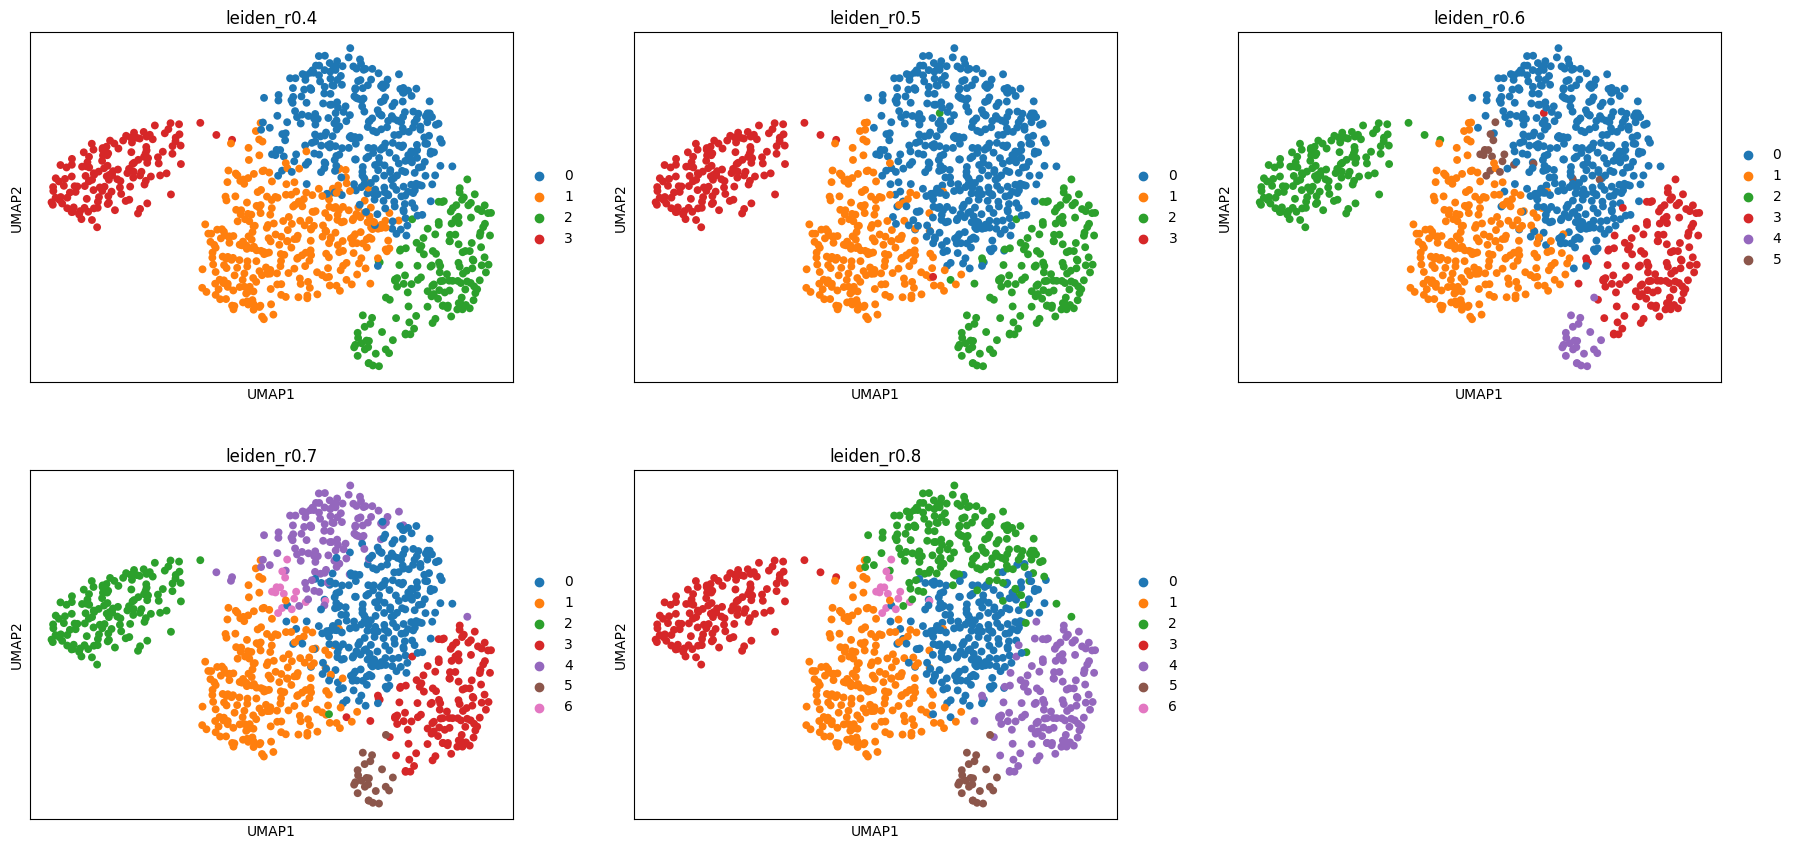

In [3]:
a=sc.read_h5ad(PROJECT_ROOT/"results/FOV46/GSM9046088_FOV46_leiden_sweep.h5ad")
CANDIDATES=[0.4,0.5,0.6,0.7,0.8]  # edit
keys=[f"leiden_r{r:g}" for r in CANDIDATES]
sc.pl.umap(a,color=keys,ncols=3,frameon=True)

## Marker-panel dotplot for one candidate
Change `SELECTED_RESOLUTION` repeatedly while inspecting.

categories: 0, 1, 2, etc.
var_group_labels: Epithelial, AT1, Tumor_epithelial, etc.


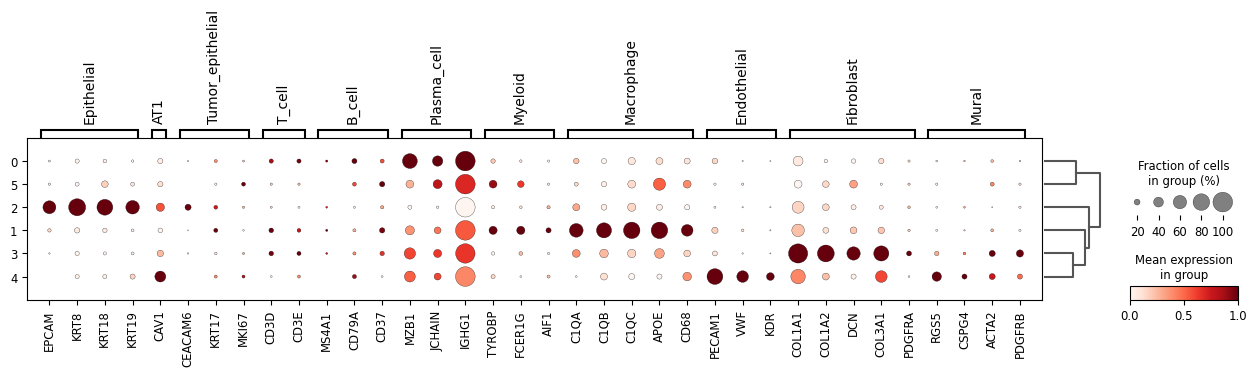

In [4]:
from config.markers import MARKER_PANEL
SELECTED_RESOLUTION=0.6  # EDIT after inspection
key=f"leiden_r{SELECTED_RESOLUTION:g}"
present={ct:[g for g in genes if g in a.raw.var_names] for ct,genes in MARKER_PANEL.items()}
present={ct:g for ct,g in present.items() if g}
sc.pl.dotplot(a,var_names=present,groupby=key,use_raw=True,standard_scale="var",dendrogram=True)

## Top DE genes for the candidate resolution

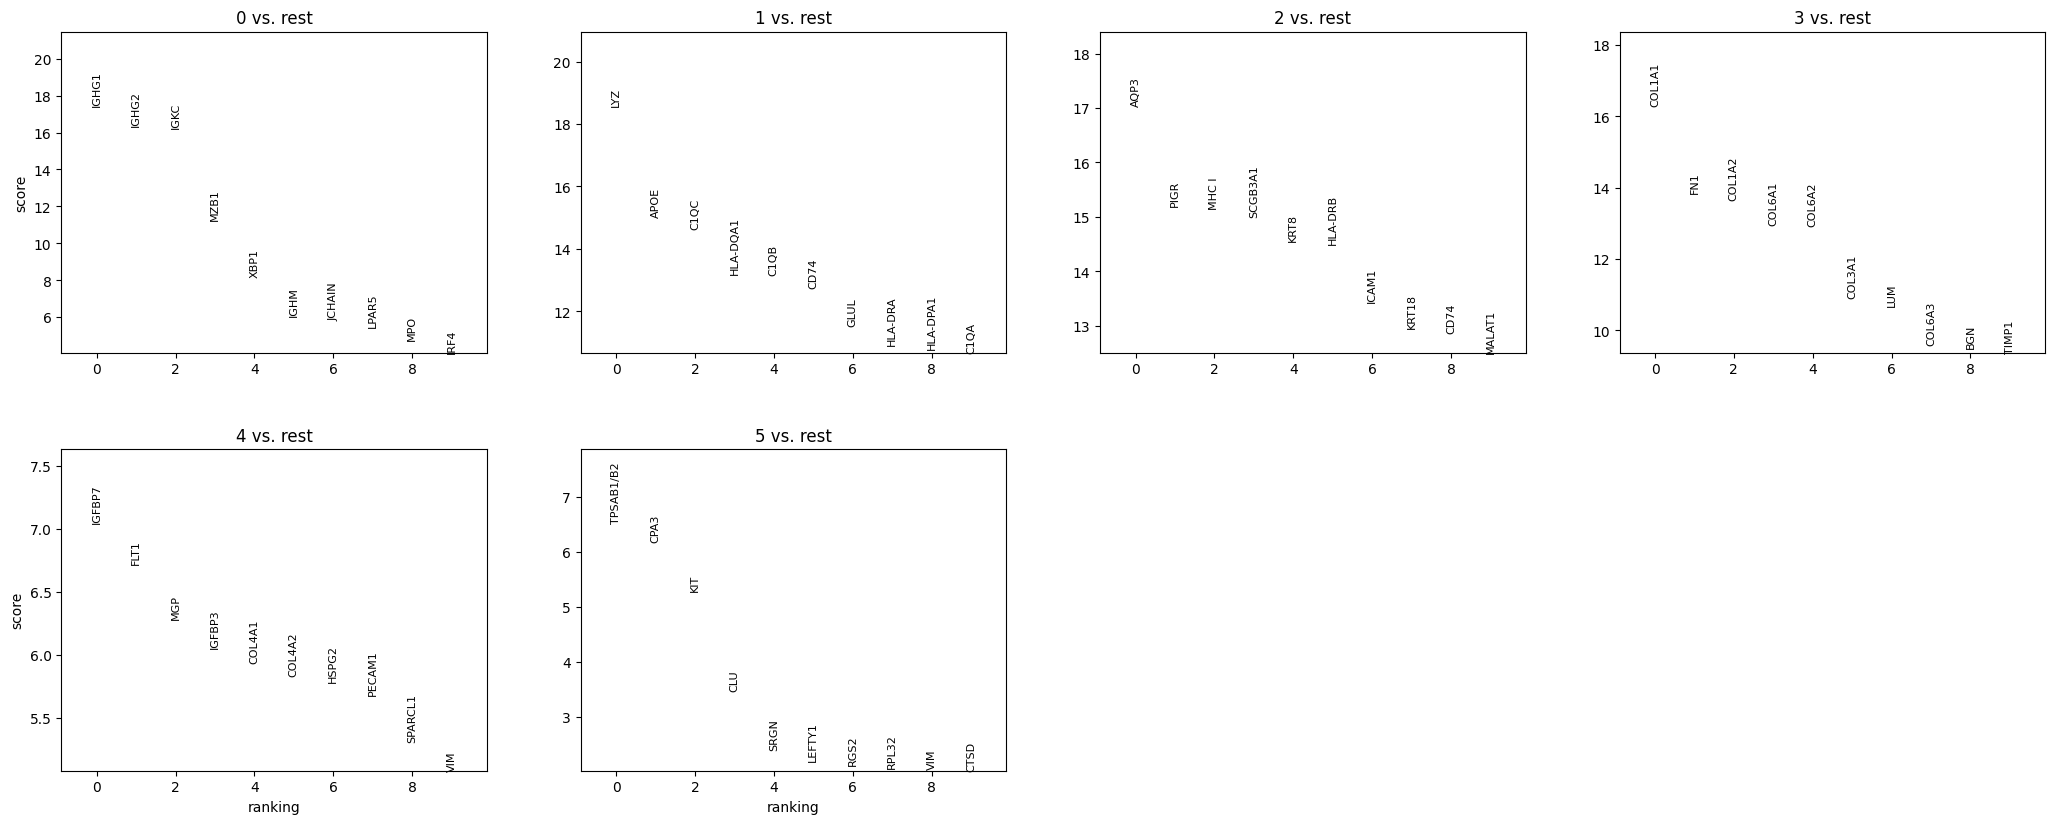

,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference
0,0,IGHG1,17.453619,1.673616,3.231004e-68,3.231004e-65,1.000000,0.994652
1,0,IGHG2,16.342541,2.153990,4.916033e-60,1.638678e-57,0.986737,0.926916
2,0,IGKC,16.257982,1.219864,1.960920e-59,4.902300e-57,1.000000,0.998217
3,0,MZB1,11.245230,2.732463,2.444588e-29,2.222353e-27,0.689655,0.331551
4,0,XBP1,8.186818,1.462670,2.682223e-16,1.166184e-14,0.745358,0.575758
5,0,IGHM,6.062129,1.609525,1.343310e-09,2.633941e-08,0.578249,0.415330
6,0,JCHAIN,5.842372,1.835156,5.146265e-09,9.028536e-08,0.427056,0.217469
7,0,LPAR5,5.471440,1.644501,4.463943e-08,6.662602e-07,0.405836,0.199643
8,0,MPO,4.761653,1.573225,1.920134e-06,2.258982e-05,0.344828,0.172906
9,0,IRF4,4.062437,1.489082,4.856311e-05,4.335992e-04,0.297082,0.142602


In [5]:
rank_key=f"rank_{key}_interactive"
sc.tl.rank_genes_groups(a,groupby=key,method="wilcoxon",use_raw=True,pts=True,key_added=rank_key)
sc.pl.rank_genes_groups(a,key=rank_key,n_genes=10,sharey=False)
markers=sc.get.rank_genes_groups_df(a,group=None,key=rank_key)
display(markers.groupby("group",observed=True).head(10))

## Record the manual choice
After inspecting the plots, edit `config/fov46_annotation.json`. Do **not** use this cell to invent cell-type labels.

In [6]:
CFG=PROJECT_ROOT/"config/fov46_annotation.json"
print(CFG.read_text())

{
  "resolution": 0.6,
  "cluster_annotations": {
    "0": "Plasma_cell",
    "1": "Macrophage",
    "2": "Epithelial",
    "3": "Fibroblast",
    "4": "Endothelial",
    "5": "Plasma_cell"
  }
}

